EXPT NO: 7

Clustering using K-Means and Gaussian Mixture Models (GMM)


DATE: 10.04.2026



SCENARIO 1 – CLUSTERING USING K-MEANS

Problem Statement

Group customers/data points into clusters based on similarity using K-Means clustering.


NEHA.N.K | 24BAD078
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


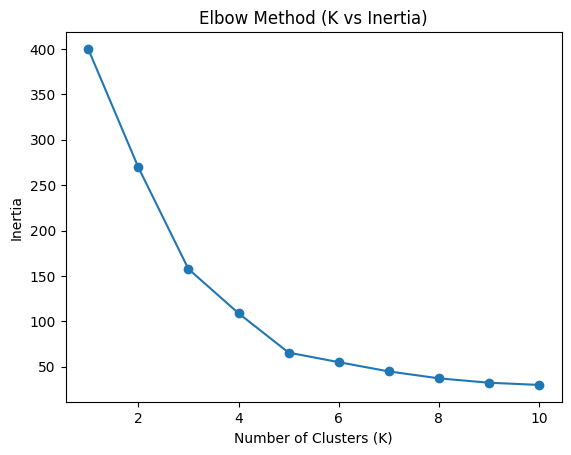


Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


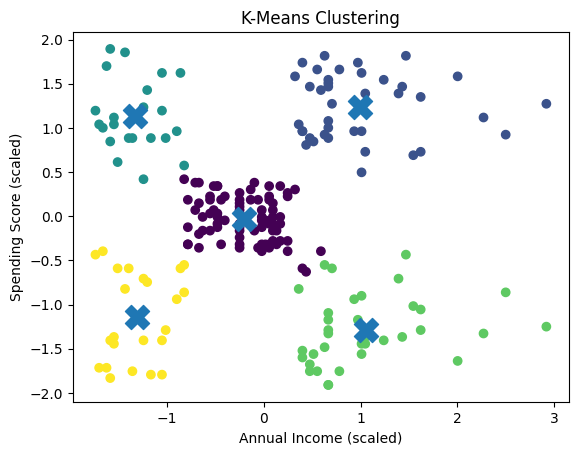


Cluster Means:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [1]:
# NEHA.N.K | 24BAD078
# Imported Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
print("NEHA.N.K | 24BAD078")
# Dataset loaded
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

# Data Preprocessing
# Checking for  missing values
print("\nMissing Values:\n", df.isnull().sum())
# Filling missing values with mean if any
df.fillna(df.mean(numeric_only=True), inplace=True)

# Selecting features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

# Plots Elbow Curve
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method (K vs Inertia)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# Applying K-Means (fornK=5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Assigning Cluster Labels
df['Cluster'] = clusters

# Evaluation Metrics
print("\nInertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

# Visualization
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, label='Data Points')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
s=300,              # bigger size
marker='X',         # different shape
label='Centroids')
plt.title("K-Means Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# Cluster Characteristics
print("\nCluster Means:")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

Analysis

**Effect of K:**

Increasing K reduces inertia but too large K causes overfitting

**Compactness & Separation:**

Good clustering shows low inertia and high silhouette score

**Customer Segments**:

High income – High spending

High income – Low spending

Low income – High spending

Low income – Low spending

Average customers

**Sensitivity to Initialization:**

Results vary with initial centroids; fixed using random_state

SCENARIO 2 – CLUSTERING USING GMM

Problem Statement


Cluster data using Gaussian Mixture Models to capture probabilistic cluster membership.


NEHA.N.K | 24BAD078

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245

Cluster probabilities:
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]

GMM Cluster Means:
             Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                            
0                     55.642857               49.369048
1                     86.538462               82.128205
2                   

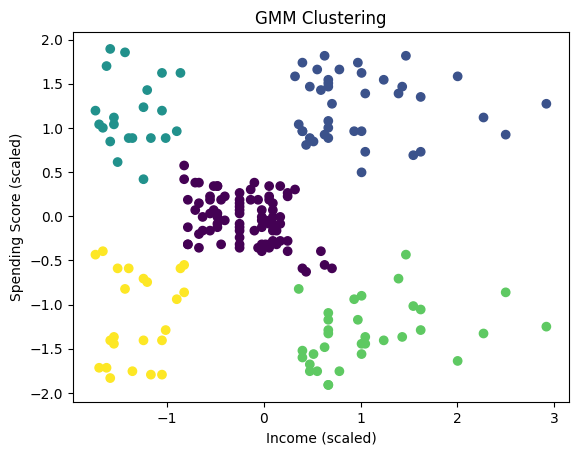

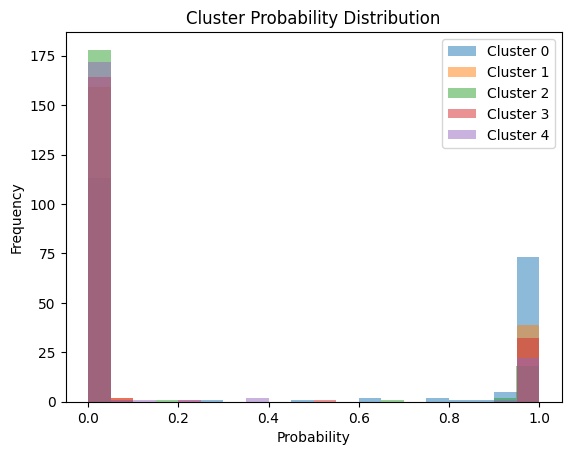

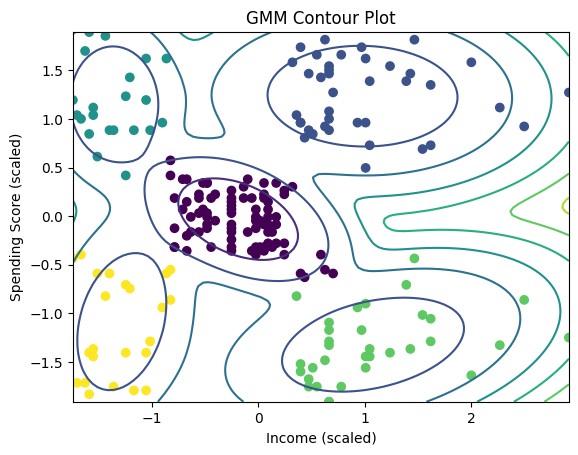

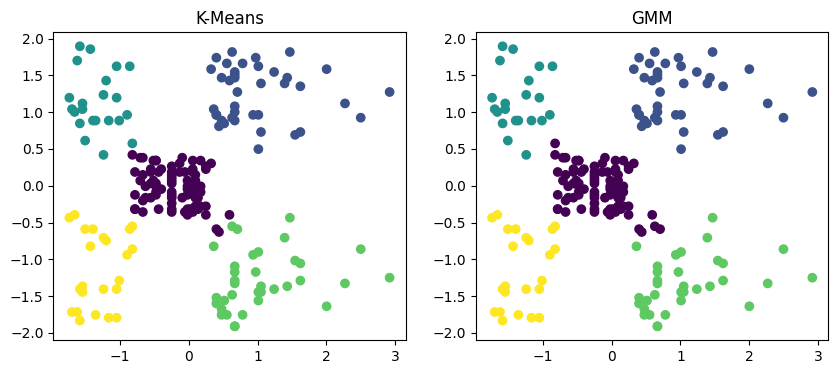

In [4]:
# NEHA.N.K | 24BAD078
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
print("NEHA.N.K | 24BAD078")
# Loading Dataset
df = pd.read_csv("Mall_Customers.csv")

# Preprocessing
print("\nMissing Values:\n", df.isnull().sum())

# Handle missing values
df = df.dropna()

# Selecting features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# number of components (K)
n_components = 5   # same as K-Means for comparison

# Applying GMM
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm.fit(X_scaled)

# Predicting probabilities
probs = gmm.predict_proba(X_scaled)

# Assigning clusters (highest probability)
clusters = gmm.predict(X_scaled)
df['GMM_Cluster'] = clusters

# Evaluation Metrics
print("\nLog-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

# Comparing with K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
k_clusters = kmeans.fit_predict(X_scaled)

print("\nCluster probabilities:")
print (probs[:5])

# Cluster Characteristics
print("\nGMM Cluster Means:")
print(df.groupby('GMM_Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

#  Visualization (Clusters)
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("GMM Clustering")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

plt.figure()
for i in range(probs.shape[1]):
    plt.hist(probs[:, i], bins=20, alpha=0.5, label=f'Cluster {i}')
plt.title("Cluster Probability Distribution")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# GMM CONTOUR PLOT
# Create grid
x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)
grid = np.array([X_grid.ravel(), Y_grid.ravel()]).T

# Compute log likelihood
Z = -gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

# Plot contour
plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("GMM Contour Plot")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# Plot comparison
plt.figure(figsize=(10,4))

# K-Means
plt.subplot(1,2,1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=k_clusters)
plt.title("K-Means")

# GMM
plt.subplot(1,2,2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("GMM")
plt.show()



Analysis


**Soft vs Hard Clustering**

K-Means → hard assignment
GMM → probabilistic (soft clustering)

**Overlapping Clusters**

GMM allows overlap
Points can belong to multiple clusters


**Cluster Shapes**

K-Means → spherical
GMM → elliptical (more flexible)

**Flexibility**
GMM handles complex data better than K-Means